In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [4]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [5]:
df['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [6]:
df['Male'] =df['Sex'].map({'M':True, 'F':False})
df.drop(columns=["Sex"])

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Male
0,40,ATA,140,289,0,Normal,172,N,0.0,Up,0,True
1,49,NAP,160,180,0,Normal,156,N,1.0,Flat,1,False
2,37,ATA,130,283,0,ST,98,N,0.0,Up,0,True
3,48,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,False
4,54,NAP,150,195,0,Normal,122,N,0.0,Up,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,TA,110,264,0,Normal,132,N,1.2,Flat,1,True
914,68,ASY,144,193,1,Normal,141,N,3.4,Flat,1,True
915,57,ASY,130,131,0,Normal,115,Y,1.2,Flat,1,True
916,57,ATA,130,236,0,LVH,174,N,0.0,Flat,1,False


In [7]:
import seaborn as sns

# Apply the default theme
sns.set_theme()

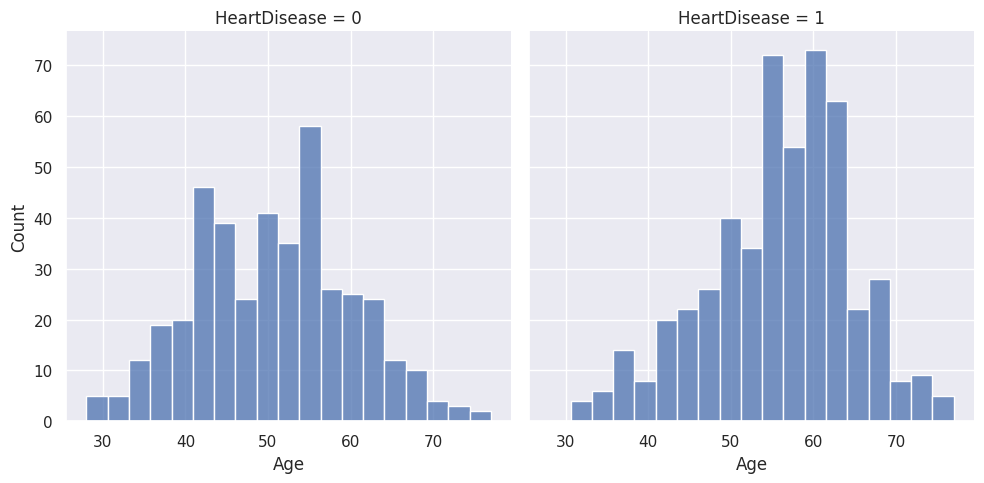

In [8]:
sns.displot(data=df, x="Age", col="HeartDisease", kde=False)


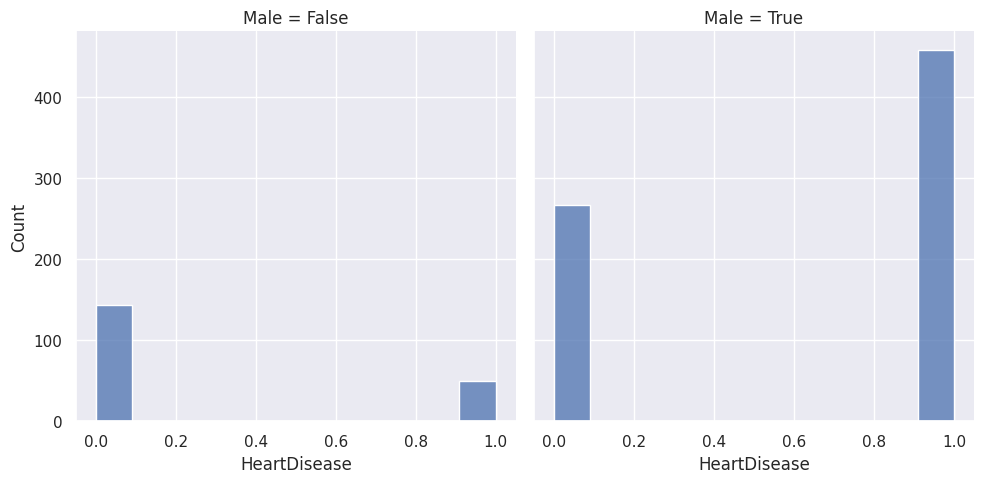

In [9]:
sns.displot(data=df, x="HeartDisease", col="Male", kde=False)


In [10]:
df = pd.get_dummies(df, columns=['ChestPainType'], drop_first=False)
df

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Male,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,M,140,289,0,Normal,172,N,0.0,Up,0,True,False,True,False,False
1,49,F,160,180,0,Normal,156,N,1.0,Flat,1,False,False,False,True,False
2,37,M,130,283,0,ST,98,N,0.0,Up,0,True,False,True,False,False
3,48,F,138,214,0,Normal,108,Y,1.5,Flat,1,False,True,False,False,False
4,54,M,150,195,0,Normal,122,N,0.0,Up,0,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,110,264,0,Normal,132,N,1.2,Flat,1,True,False,False,False,True
914,68,M,144,193,1,Normal,141,N,3.4,Flat,1,True,True,False,False,False
915,57,M,130,131,0,Normal,115,Y,1.2,Flat,1,True,True,False,False,False
916,57,F,130,236,0,LVH,174,N,0.0,Flat,1,False,False,True,False,False


In [11]:
df = pd.get_dummies(df, columns=['RestingECG'], drop_first=False)


In [12]:
df=df.drop(columns=['Sex'])

In [13]:
df['ExerciseAngina']=df['ExerciseAngina'].map({"N":0,"Y":1})

In [14]:
df['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [15]:
df = pd.get_dummies(df, columns=['ST_Slope'], drop_first=False)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [17]:
X = df.drop('HeartDisease', axis=1)  # Features (everything except target)
y = df['HeartDisease'] 

In [18]:
X.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,Male,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0.0,True,False,True,False,False,False,True,False,False,False,True
1,49,160,180,0,156,0,1.0,False,False,False,True,False,False,True,False,False,True,False
2,37,130,283,0,98,0,0.0,True,False,True,False,False,False,False,True,False,False,True
3,48,138,214,0,108,1,1.5,False,True,False,False,False,False,True,False,False,True,False
4,54,150,195,0,122,0,0.0,True,False,False,True,False,False,True,False,False,False,True


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
y_test

668    0
30     1
377    1
535    1
807    0
      ..
211    1
745    1
584    1
878    0
451    1
Name: HeartDisease, Length: 184, dtype: int64

In [21]:

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
y_pred = model.predict(X_test)
X_test
# accuracy = accuracy_score(y_test, y_pred)
# print(f'Accuracy of model on historical data: {accuracy * 100:.2f}%')

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,Male,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,63,140,195,0,179,0,0.0,False,False,True,False,False,False,True,False,False,False,True
30,53,145,518,0,130,0,0.0,True,False,False,True,False,False,True,False,False,True,False
377,65,160,0,1,122,0,1.2,True,True,False,False,False,False,False,True,False,True,False
535,56,130,0,0,122,1,1.0,True,True,False,False,False,True,False,False,False,True,False
807,54,108,309,0,156,0,0.0,True,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,50,140,288,0,140,1,0.0,False,False,False,True,False,False,True,False,False,True,False
745,63,108,269,0,169,1,1.8,False,True,False,False,False,False,True,False,False,True,False
584,64,141,244,1,116,1,1.5,True,True,False,False,False,False,False,True,False,True,False
878,49,130,266,0,171,0,0.6,True,False,True,False,False,False,True,False,False,False,True


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   ExerciseAngina     918 non-null    int64  
 6   Oldpeak            918 non-null    float64
 7   HeartDisease       918 non-null    int64  
 8   Male               918 non-null    bool   
 9   ChestPainType_ASY  918 non-null    bool   
 10  ChestPainType_ATA  918 non-null    bool   
 11  ChestPainType_NAP  918 non-null    bool   
 12  ChestPainType_TA   918 non-null    bool   
 13  RestingECG_LVH     918 non-null    bool   
 14  RestingECG_Normal  918 non-null    bool   
 15  RestingECG_ST      918 non-null    bool   
 16  ST_Slope_Down      918 non-null    bo

In [24]:


# New data for prediction
new_data = pd.DataFrame({
    'Age': [45],
    'RestingBP': [130],
    'Cholesterol': [250],
    'FastingBS': [0],  # 0 means normal fasting blood sugar
    'MaxHR': [160],
    'ExerciseAngina': [1],  # 1 means yes
    'Oldpeak': [1.0],
    'Male': [1],  # 1 for male
    'ChestPainType_ASY': [1],  # Assuming the patient has ASY type chest pain
    'ChestPainType_ATA': [0],  # Patient does not have ATA type chest pain
    'ChestPainType_NAP': [0],  # Patient does not have NAP type chest pain
    'ChestPainType_TA': [0],  # Patient does not have TA type chest pain
    'RestingECG_LVH': [0],  # Patient does not have LVH
    'RestingECG_Normal': [1],  # Patient has a normal resting ECG
    'RestingECG_ST': [0],  # Patient does not have ST deviation
    'ST_Slope_Down': [0],  # Patient does not have downward slope
    'ST_Slope_Flat': [1],  # Patient has a flat slope
    'ST_Slope_Up': [0],  # Patient does not have an upward slope
})
prediction = model.predict(new_data)
print(f'Predicted Heart Disease Risk (0: No, 1: Yes): {prediction[0]}')
# Display the new data


Predicted Heart Disease Risk (0: No, 1: Yes): 1


In [25]:
new_data_no_risk = pd.DataFrame({
    'Age': [70],
    'RestingBP': [120],
    'Cholesterol': [180],
    'FastingBS': [1],  # 0 means normal fasting blood sugar
    'MaxHR': [150],
    'ExerciseAngina': [0],  # 0 means no exercise-induced angina
    'Oldpeak': [0.0],  # No depression of the ST segment
    'Male': [True],  # 0 for female
    'ChestPainType_ASY': [True],  # No ASY type chest pain
    'ChestPainType_ATA': [False],  # Patient has ATA type chest pain
    'ChestPainType_NAP': [False],  # No NAP type chest pain
    'ChestPainType_TA': [False],  # No TA type chest pain
    'RestingECG_LVH': [False],  # No LVH
    'RestingECG_Normal': [True],  # Normal ECG
    'RestingECG_ST': [False],  # No ST deviation
    'ST_Slope_Down': [False],  # No downward slope
    'ST_Slope_Flat': [False],  # No flat slope
    'ST_Slope_Up': [True],  # Has upward slope
})

prediction_no_risk = model.predict(new_data_no_risk)
print(f'Predicted Heart Disease Risk (0: No, 1: Yes): {prediction_no_risk[0]}')

Predicted Heart Disease Risk (0: No, 1: Yes): 0


Accuracy: 0.8967391304347826
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        77
           1       0.92      0.90      0.91       107

    accuracy                           0.90       184
   macro avg       0.89      0.90      0.89       184
weighted avg       0.90      0.90      0.90       184



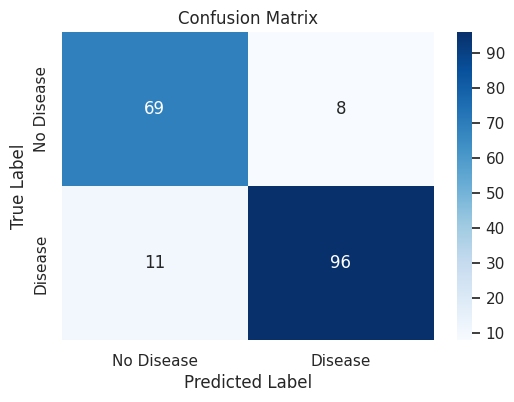

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()